In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/m5-forecasting-uncertainty/calendar.csv
/kaggle/input/competitions/m5-forecasting-uncertainty/sample_submission.csv
/kaggle/input/competitions/m5-forecasting-uncertainty/sell_prices.csv
/kaggle/input/competitions/m5-forecasting-uncertainty/sales_train_validation.csv
/kaggle/input/competitions/m5-forecasting-uncertainty/sales_train_evaluation.csv


In [2]:
!pip install lightgbm -q

In [3]:
# imports and load data
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

P = "/kaggle/input/competitions/m5-forecasting-uncertainty/"
cal = pd.read_csv(P + "calendar.csv", parse_dates=["date"])
prices = pd.read_csv(P + "sell_prices.csv")
sales = pd.read_csv(P + "sales_train_evaluation.csv")

# Subset: one store, one department, 150 random items
sub = sales[(sales.store_id == "CA_1") & (sales.dept_id == "FOODS_3")]
sub = sub.sample(150, random_state=42)

id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sub.columns if c.startswith("d_")][-900:]

# Wide -> long
df = sub.melt(id_vars=id_cols, value_vars=day_cols, var_name="d", value_name="sales")

# Attach calendar and prices
df = df.merge(cal[["d", "date", "wm_yr_wk", "wday", "month", "year",
                   "event_name_1", "event_type_1", "snap_CA"]], on="d", how="left")
df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

# Missing price = item not on sale yet that week -> drop
df = df.dropna(subset=["sell_price"])
df = df.sort_values(["id", "date"]).reset_index(drop=True)
print(df.shape)
df.head()

(131496, 17)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,snap_CA,sell_price
0,FOODS_3_006_CA_1_evaluation,FOODS_3_006,FOODS_3,FOODS,CA_1,CA,d_1114,1,2014-02-15,11403,1,2,2014,NaN,NaN,0,7.88
1,FOODS_3_006_CA_1_evaluation,FOODS_3_006,FOODS_3,FOODS,CA_1,CA,d_1115,0,2014-02-16,11403,2,2,2014,NaN,NaN,0,7.88
2,FOODS_3_006_CA_1_evaluation,FOODS_3_006,FOODS_3,FOODS,CA_1,CA,d_1116,1,2014-02-17,11403,3,2,2014,PresidentsDay,National,0,7.88
3,FOODS_3_006_CA_1_evaluation,FOODS_3_006,FOODS_3,FOODS,CA_1,CA,d_1117,0,2014-02-18,11403,4,2,2014,NaN,NaN,0,7.88
4,FOODS_3_006_CA_1_evaluation,FOODS_3_006,FOODS_3,FOODS,CA_1,CA,d_1118,0,2014-02-19,11403,5,2,2014,NaN,NaN,0,7.88


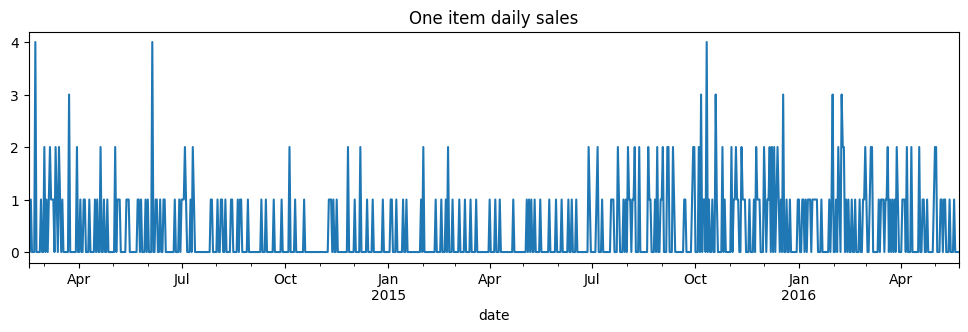

Share of zero-sales days: 0.424
count    131496.000000
mean          3.712326
std           8.627084
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max         157.000000
Name: sales, dtype: float64


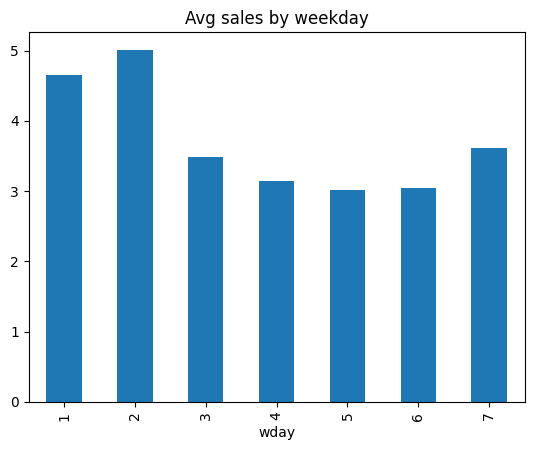

event_name_1
False    3.728479
True     3.534284
Name: sales, dtype: float64


In [4]:
one = df[df.id == df.id.iloc[0]].set_index("date")["sales"]
one.plot(figsize=(12, 3), title="One item daily sales")
plt.show()

print("Share of zero-sales days:", round((df.sales == 0).mean(), 3))
print(df.sales.describe())

df.groupby("wday")["sales"].mean().plot(kind="bar", title="Avg sales by weekday")
plt.show()
print(df.groupby(df.event_name_1.notna())["sales"].mean())

In [5]:
g = df.groupby("id")["sales"]

# Lags (all >= 28 days, so no leakage)
for lag in [28, 35, 42, 56]:
    df[f"lag_{lag}"] = g.shift(lag)

# Rolling stats on the 28-day-shifted series
s28 = g.shift(28)
for w in [7, 28]:
    df[f"rmean_{w}"] = s28.groupby(df["id"]).transform(lambda s: s.rolling(w).mean())
    df[f"rstd_{w}"]  = s28.groupby(df["id"]).transform(lambda s: s.rolling(w).std())

# Price and promotion features
df["price_rel"] = df.sell_price / df.groupby("id")["sell_price"].transform("median")
df["is_promo"] = (df.price_rel < 0.95).astype(int)
df["price_change"] = df.sell_price / df.groupby("id")["sell_price"].shift(7) - 1

# Calendar and events
df["dayofweek"] = df.date.dt.dayofweek
df["dayofmonth"] = df.date.dt.day
df["weekofyear"] = df.date.dt.isocalendar().week.astype(int)
df["has_event"] = df.event_name_1.notna().astype(int)
df["event_type"] = df.event_type_1.fillna("None").astype("category").cat.codes
df["snap"] = df.snap_CA
df["item_code"] = df.item_id.astype("category").cat.codes

features = ["lag_28", "lag_35", "lag_42", "lag_56",
            "rmean_7", "rmean_28", "rstd_7", "rstd_28",
            "sell_price", "price_rel", "is_promo", "price_change",
            "dayofweek", "dayofmonth", "weekofyear", "month",
            "has_event", "event_type", "snap", "item_code"]

# Drop rows only where a FEATURE is missing (not the event name columns)
df = df.dropna(subset=features).reset_index(drop=True)
print(df.shape)

(123096, 35)


In [6]:
last = df.date.max()
test_start  = last - pd.Timedelta(days=55)    # final 56 days
valid_start = test_start - pd.Timedelta(days=56)

train = df[df.date < valid_start]
valid = df[(df.date >= valid_start) & (df.date < test_start)].copy()
test  = df[df.date >= test_start].copy()
print(len(train), len(valid), len(test))

106296 8400 8400


In [7]:
base = test["lag_28"]
print("Baseline MAE :", mean_absolute_error(test.sales, base))
print("Baseline RMSE:", np.sqrt(mean_squared_error(test.sales, base)))

Baseline MAE : 2.3533333333333335
Baseline RMSE: 5.137768646666242


In [8]:
quantiles = [0.1, 0.5, 0.9]
models = {}
for q in quantiles:
    m = lgb.LGBMRegressor(objective="quantile", alpha=q, n_estimators=600,
                          learning_rate=0.05, num_leaves=63,
                          random_state=42, verbose=-1)
    m.fit(train[features], train.sales,
          eval_set=[(valid[features], valid.sales)],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    models[q] = m
    print(f"q={q} done")

for d in (valid, test):
    for q in quantiles:
        d[f"p{int(q*100)}"] = models[q].predict(d[features])
    d[["p10", "p50", "p90"]] = np.sort(d[["p10", "p50", "p90"]].values, axis=1)
    d[["p10", "p50", "p90"]] = d[["p10", "p50", "p90"]].clip(lower=0)

print("Model MAE :", mean_absolute_error(test.sales, test.p50))
print("Model RMSE:", np.sqrt(mean_squared_error(test.sales, test.p50)))

q=0.1 done
q=0.5 done
q=0.9 done
Model MAE : 1.970728275355062
Model RMSE: 4.240187315911431


In [9]:
def coverage(d, lo="p10", hi="p90"):
    return ((d.sales >= d[lo]) & (d.sales <= d[hi])).mean()

print("Target coverage : 80%")
print(f"Valid coverage  : {coverage(valid):.1%}")
print(f"Test coverage   : {coverage(test):.1%}")
print(f"Avg width       : {(test.p90 - test.p10).mean():.2f} units")

for q in quantiles:
    frac = (test.sales < test[f"p{int(q*100)}"]).mean()
    print(f"P{int(q*100)}: {frac:.1%} of actuals below it (ideal {q:.0%})")

Target coverage : 80%
Valid coverage  : 87.4%
Test coverage   : 87.6%
Avg width       : 6.86 units
P10: 1.1% of actuals below it (ideal 10%)
P50: 50.1% of actuals below it (ideal 50%)
P90: 88.7% of actuals below it (ideal 90%)


In [10]:
# Upper-side calibration: make P90 cover 90% of actuals
score_hi = valid.sales - valid.p90
n = len(score_hi)
qhat_hi = np.quantile(score_hi, min(1, np.ceil((n + 1) * 0.90) / n))
print("Upper adjustment (units):", round(qhat_hi, 2))

test["p10_cal"] = test.p10                      # lower side stays (stuck at the 0 floor)
test["p90_cal"] = test.p90 + max(qhat_hi, 0)

print(f"P90 before: {(test.sales < test.p90).mean():.1%} of actuals below (ideal 90%)")
print(f"P90 after : {(test.sales < test.p90_cal).mean():.1%} of actuals below (ideal 90%)")
print(f"Interval coverage before: {coverage(test):.1%}")
print(f"Interval coverage after : {coverage(test, 'p10_cal', 'p90_cal'):.1%}")

Upper adjustment (units): 0.18
P90 before: 88.7% of actuals below (ideal 90%)
P90 after : 90.0% of actuals below (ideal 90%)
Interval coverage before: 87.6%
Interval coverage after : 89.0%


            Strategy  Total cost  Units short  Units leftover  Fill rate
Point forecast (P50)     54887.0       9454.0          7617.0      0.690
    P50 + 20% buffer     47282.0       7206.0         11252.0      0.764
Upper quantile (P90)     42900.0       1772.0         34040.0      0.942
      Calibrated P90     43764.0       1646.0         35534.0      0.946


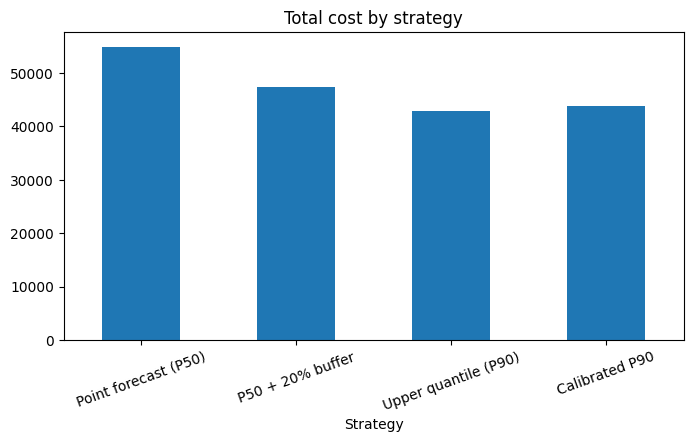

In [11]:
c_under, c_over = 5.0, 1.0   # assumptions: a stockout costs 5, a leftover unit costs 1

def evaluate(demand, stock):
    short = np.maximum(demand - stock, 0).sum()
    left  = np.maximum(stock - demand, 0).sum()
    return c_under * short + c_over * left, short, left

strategies = {
    "Point forecast (P50)": test.p50,
    "P50 + 20% buffer":     test.p50 * 1.2,
    "Upper quantile (P90)": test.p90,
    "Calibrated P90":       test.p90_cal,
}
rows = []
for name, stock in strategies.items():
    cost, short, left = evaluate(test.sales, np.ceil(stock))
    rows.append([name, cost, short, left, 1 - short / test.sales.sum()])

res = pd.DataFrame(rows, columns=["Strategy", "Total cost", "Units short",
                                  "Units leftover", "Fill rate"])
print(res.round(3).to_string(index=False))

res.set_index("Strategy")["Total cost"].plot(kind="bar", figsize=(8, 4),
                                             title="Total cost by strategy")
plt.xticks(rotation=20)
plt.savefig("cost_by_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
test["covered"] = ((test.sales >= test.p10) & (test.sales <= test.p90)).astype(int)
test["spike"] = (test.sales > test.rmean_28 + 2 * test.rstd_28).astype(int)

for col in ["is_promo", "has_event", "snap", "spike", "dayofweek"]:
    print(f"\nCoverage by {col}")
    print(test.groupby(col)["covered"].mean().round(3))

# Slow vs fast-moving items
test["avg_level"] = test.groupby("id")["sales"].transform("mean")
test["speed"] = pd.qcut(test.avg_level.rank(method="first"), 4,
                        labels=["slowest", "slow", "fast", "fastest"])
print("\nCoverage by item speed")
print(test.groupby("speed", observed=True)["covered"].mean().round(3))


Coverage by is_promo
is_promo
0    0.876
1    0.878
Name: covered, dtype: float64

Coverage by has_event
has_event
0    0.875
1    0.887
Name: covered, dtype: float64

Coverage by snap
snap
0    0.876
1    0.877
Name: covered, dtype: float64

Coverage by spike
spike
0    0.941
1    0.299
Name: covered, dtype: float64

Coverage by dayofweek
dayofweek
0    0.853
1    0.876
2    0.882
3    0.875
4    0.877
5    0.888
6    0.882
Name: covered, dtype: float64

Coverage by item speed
speed
slowest    0.921
slow       0.890
fast       0.864
fastest    0.830
Name: covered, dtype: float64


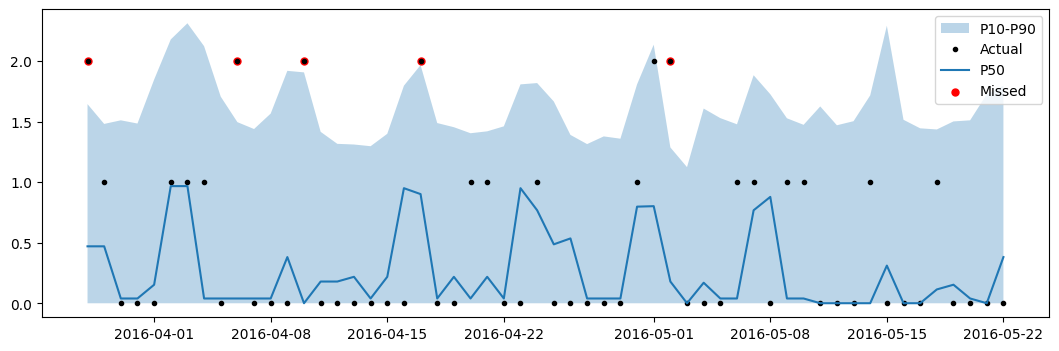

In [13]:
s = test[test.id == test.id.iloc[0]]
plt.figure(figsize=(13, 4))
plt.fill_between(s.date, s.p10, s.p90, alpha=0.3, label="P10-P90")
plt.plot(s.date, s.sales, "k.", label="Actual")
plt.plot(s.date, s.p50, label="P50")
miss = s[s.covered == 0]
plt.scatter(miss.date, miss.sales, c="red", s=25, label="Missed")
plt.legend()
plt.savefig("interval_example.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# 1. Point-forecast model (predicts the average)
point_model = lgb.LGBMRegressor(objective="regression", n_estimators=300,
                                learning_rate=0.05, num_leaves=63,
                                random_state=42, verbose=-1)
point_model.fit(train[features], train.sales)

valid["pt"] = point_model.predict(valid[features]).clip(0)
test["pt"]  = point_model.predict(test[features]).clip(0)

# 2. Residual quantiles measured on the validation set
resid = valid.sales - valid.pt
lo_r, hi_r = np.quantile(resid, 0.10), np.quantile(resid, 0.90)
print(f"Residual quantiles: 10th = {lo_r:.2f}, 90th = {hi_r:.2f}")

test["r10"] = (test.pt + lo_r).clip(lower=0)
test["r90"] = (test.pt + hi_r).clip(lower=0)

# 3. Helpers
def pinball(y, pred, q):
    e = y - pred
    return np.mean(np.maximum(q * e, (q - 1) * e))

def summarize(name, lo, hi):
    cov = ((test.sales >= lo) & (test.sales <= hi)).mean()
    return {
        "Method": name,
        "Coverage (target 80%)": round(cov, 3),
        "Avg width": round((hi - lo).mean(), 2),
        "P90 below-share (ideal 0.90)": round((test.sales < hi).mean(), 3),
        "Pinball P90": round(pinball(test.sales, hi, 0.9), 4),
    }

cmp_df = pd.DataFrame([
    summarize("Residual-based", test.r10, test.r90),
    summarize("Quantile regression", test.p10, test.p90),
    summarize("Quantile + calibrated P90", test.p10_cal, test.p90_cal),
])
print(cmp_df.to_string(index=False))

Residual quantiles: 10th = -1.96, 90th = 2.88
                   Method  Coverage (target 80%)  Avg width  P90 below-share (ideal 0.90)  Pinball P90
           Residual-based                  0.785       4.23                         0.899       0.6911
      Quantile regression                  0.876       6.86                         0.887       0.5967
Quantile + calibrated P90                  0.890       7.05                         0.900       0.5954


In [15]:
lvl = train.groupby("id")["sales"].mean()
bins = lvl.quantile([0.25, 0.5, 0.75]).values
test["vol_grp"] = np.digitize(test["id"].map(lvl).fillna(lvl.median()), bins)
test["vol_grp"] = test["vol_grp"].map({0: "slowest", 1: "slow", 2: "fast", 3: "fastest"})

test["spike"] = (test.sales > test.rmean_28 + 2 * test.rstd_28).astype(int)

test["cov_resid"] = ((test.sales >= test.r10) & (test.sales <= test.r90)).astype(int)
test["cov_quant"] = ((test.sales >= test.p10) & (test.sales <= test.p90)).astype(int)
test["p90_resid_ok"] = (test.sales < test.r90).astype(int)
test["p90_quant_ok"] = (test.sales < test.p90).astype(int)

print("Interval coverage by item volume (target 0.80)")
print(test.groupby("vol_grp", observed=True)[["cov_resid", "cov_quant"]].mean().round(3))

print("\nShare of actuals below the upper bound by item volume (ideal 0.90)")
print(test.groupby("vol_grp", observed=True)[["p90_resid_ok", "p90_quant_ok"]].mean().round(3))

print("\nInterval coverage on spike vs normal days")
print(test.groupby("spike")[["cov_resid", "cov_quant"]].mean().round(3))

Interval coverage by item volume (target 0.80)
         cov_resid  cov_quant
vol_grp                      
fast         0.768      0.859
fastest      0.461      0.850
slow         0.924      0.885
slowest      0.988      0.911

Share of actuals below the upper bound by item volume (ideal 0.90)
         p90_resid_ok  p90_quant_ok
vol_grp                            
fast            0.903         0.873
fastest         0.765         0.879
slow            0.939         0.886
slowest         0.989         0.911

Interval coverage on spike vs normal days
       cov_resid  cov_quant
spike                      
0          0.817      0.941
1          0.500      0.299


In [16]:
def evaluate(demand, stock):
    short = np.maximum(demand - stock, 0).sum()
    left  = np.maximum(stock - demand, 0).sum()
    return 5.0 * short + 1.0 * left, short, left

rows = []
for name, stock in [("Residual-based upper bound", test.r90),
                    ("Quantile P90", test.p90),
                    ("Quantile calibrated P90", test.p90_cal)]:
    cost, short, left = evaluate(test.sales, np.ceil(stock))
    rows.append([name, cost, short, left, 1 - short / test.sales.sum()])

print(pd.DataFrame(rows, columns=["Strategy", "Total cost", "Units short",
                                  "Units leftover", "Fill rate"]).round(3).to_string(index=False))

                  Strategy  Total cost  Units short  Units leftover  Fill rate
Residual-based upper bound     46218.0       3009.0         31173.0      0.901
              Quantile P90     42900.0       1772.0         34040.0      0.942
   Quantile calibrated P90     43764.0       1646.0         35534.0      0.946
